In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("SuperStoreOrders.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [6]:
df = pd.read_csv("SuperStoreOrders.csv")


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [8]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [10]:
print(df.columns.tolist())

['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year']


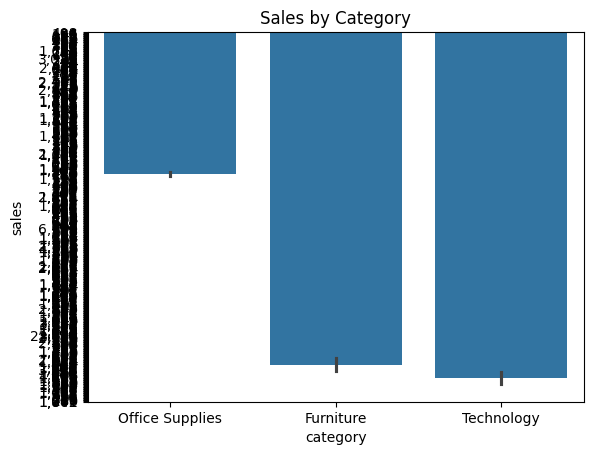

In [11]:
sns.barplot(x='category', y='sales', data=df)
plt.title("Sales by Category")
plt.show()

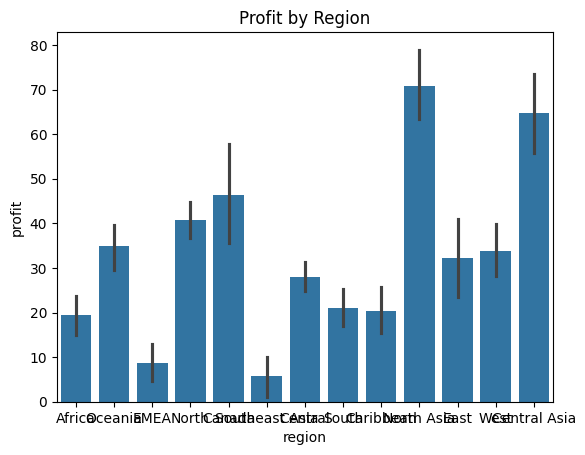

In [13]:
sns.barplot(x='region', y='profit', data=df)
plt.title("Profit by Region")
plt.show()

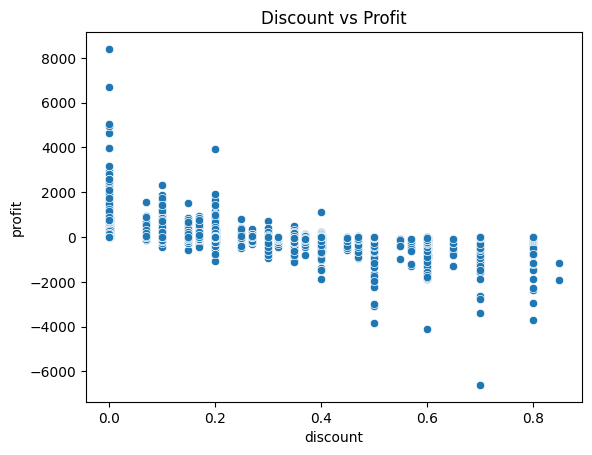

In [14]:
sns.scatterplot(x='discount', y='profit', data=df)
plt.title("Discount vs Profit")
plt.show()

In [20]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)

In [21]:
df['order_date'].head()
df['order_date'].dtype

dtype('<M8[ns]')

In [22]:
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.show()

TypeError: no numeric data to plot

In [23]:
df['sales'].dtype

dtype('O')

In [24]:
df['sales'] = df['sales'].astype(str).str.replace(',', '').str.replace('$', '')

In [25]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [26]:
df['sales'].dtype

dtype('int64')

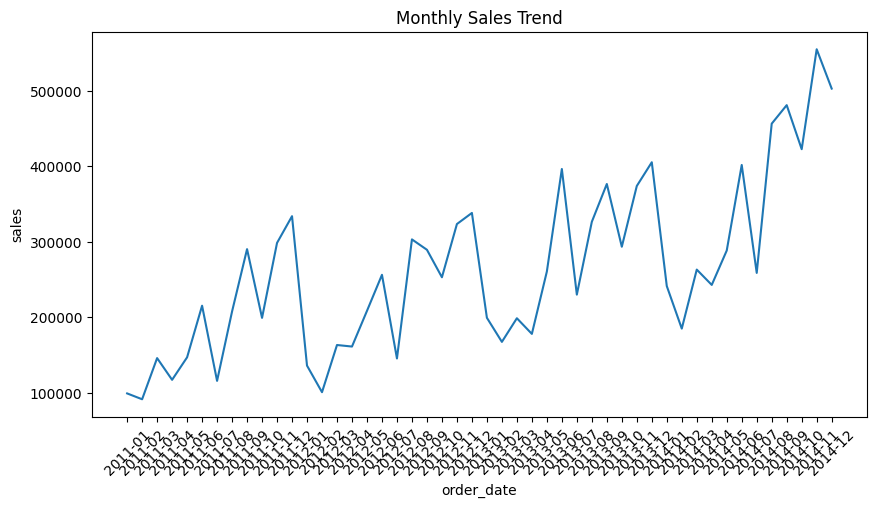

In [27]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)

monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum().reset_index()

monthly_sales['order_date'] = monthly_sales['order_date'].astype(str)

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='order_date', y='sales')

plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.show()

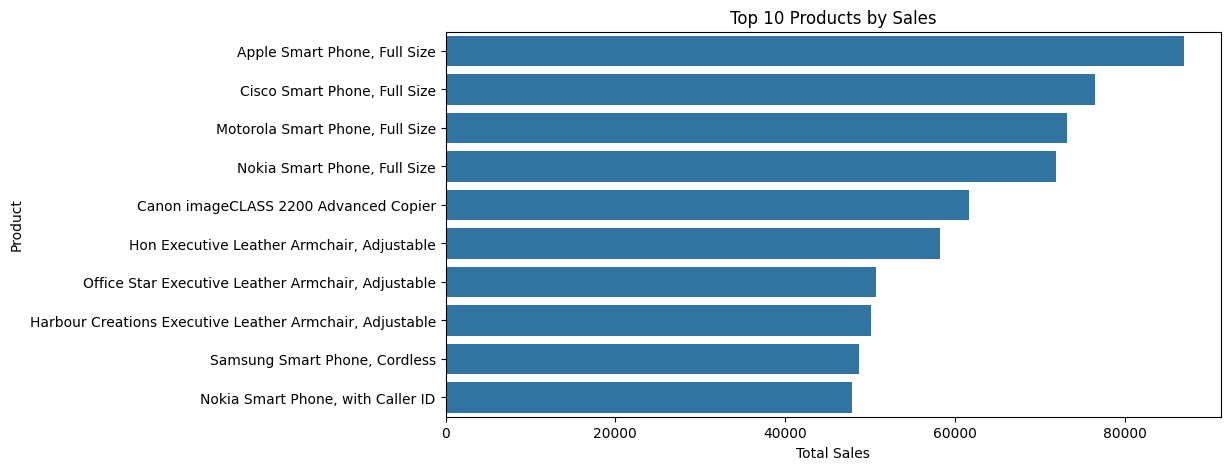

In [28]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

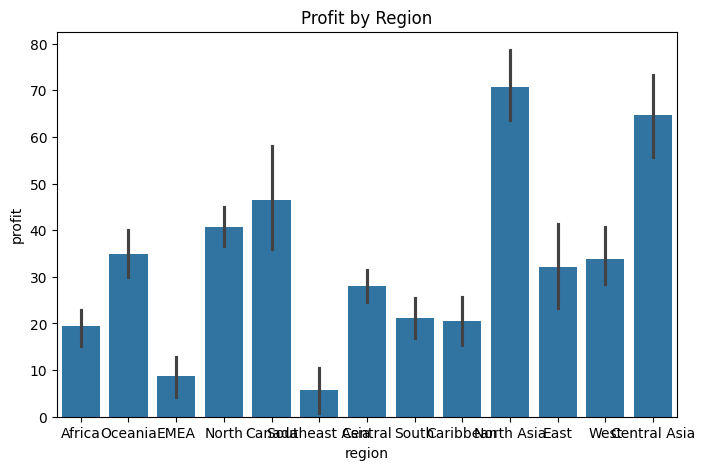

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(x='region', y='profit', data=df)

plt.title("Profit by Region")
plt.show()

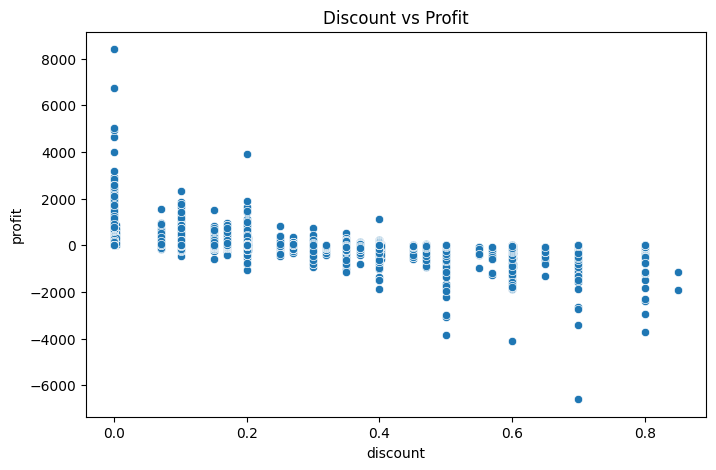

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='discount', y='profit', data=df)

plt.title("Discount vs Profit")
plt.show()

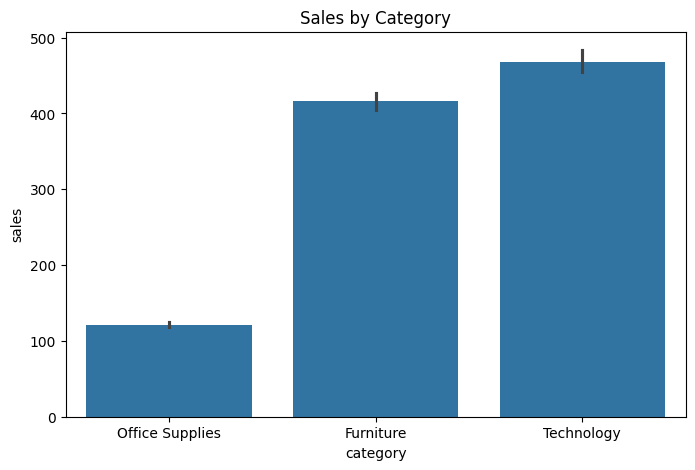

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(x='category', y='sales', data=df)

plt.title("Sales by Category")
plt.show()

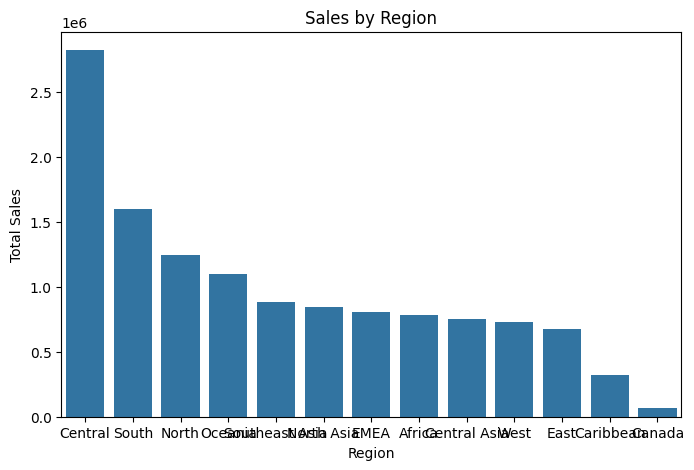

In [32]:
top_regions = df.groupby('region')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=top_regions.index, y=top_regions.values)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

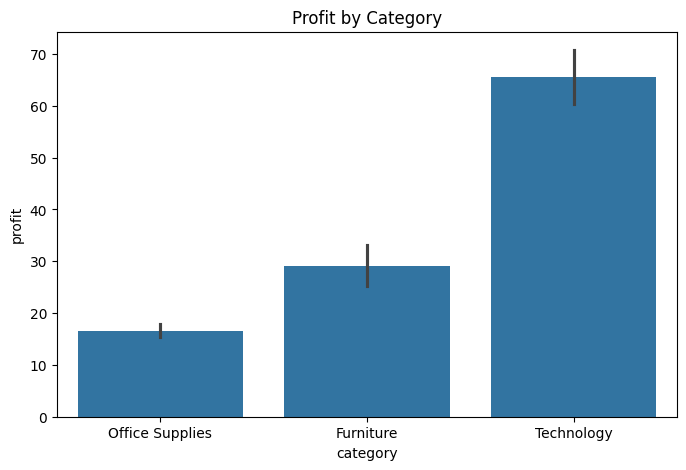

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(x='category', y='profit', data=df)

plt.title("Profit by Category")
plt.show()

In [34]:
df.to_csv("retail_analysis_clean.csv", index=False)